In [1]:
import os
os.chdir('/Users/fazedreaper/Documents/Software-Projects/Python/HeartGuard - Intro to DS Project')
print(os.getcwd())

/Users/fazedreaper/Documents/Software-Projects/Python/HeartGuard - Intro to DS Project


In [2]:
# importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# load the data
heart_df = pd.read_csv('data/heart_disease_raw.csv')

# binarize target: 0 -> no disease, 1-4 -> disease -> 1
heart_df['target'] = (heart_df['num'] > 0).astype(int)

print(heart_df.shape)
print(heart_df.dtypes)
print(heart_df.head())

(295, 15)
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
num           int64
target        int64
dtype: object
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

   ca  thal  num  target  
0   0     6    0       0  
1   3     3    2       1  
2   2     7    1       1  
3   0     3    0       0  
4   0     3    0       0  


In [4]:
# check for missing values
print(heart_df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
target      0
dtype: int64


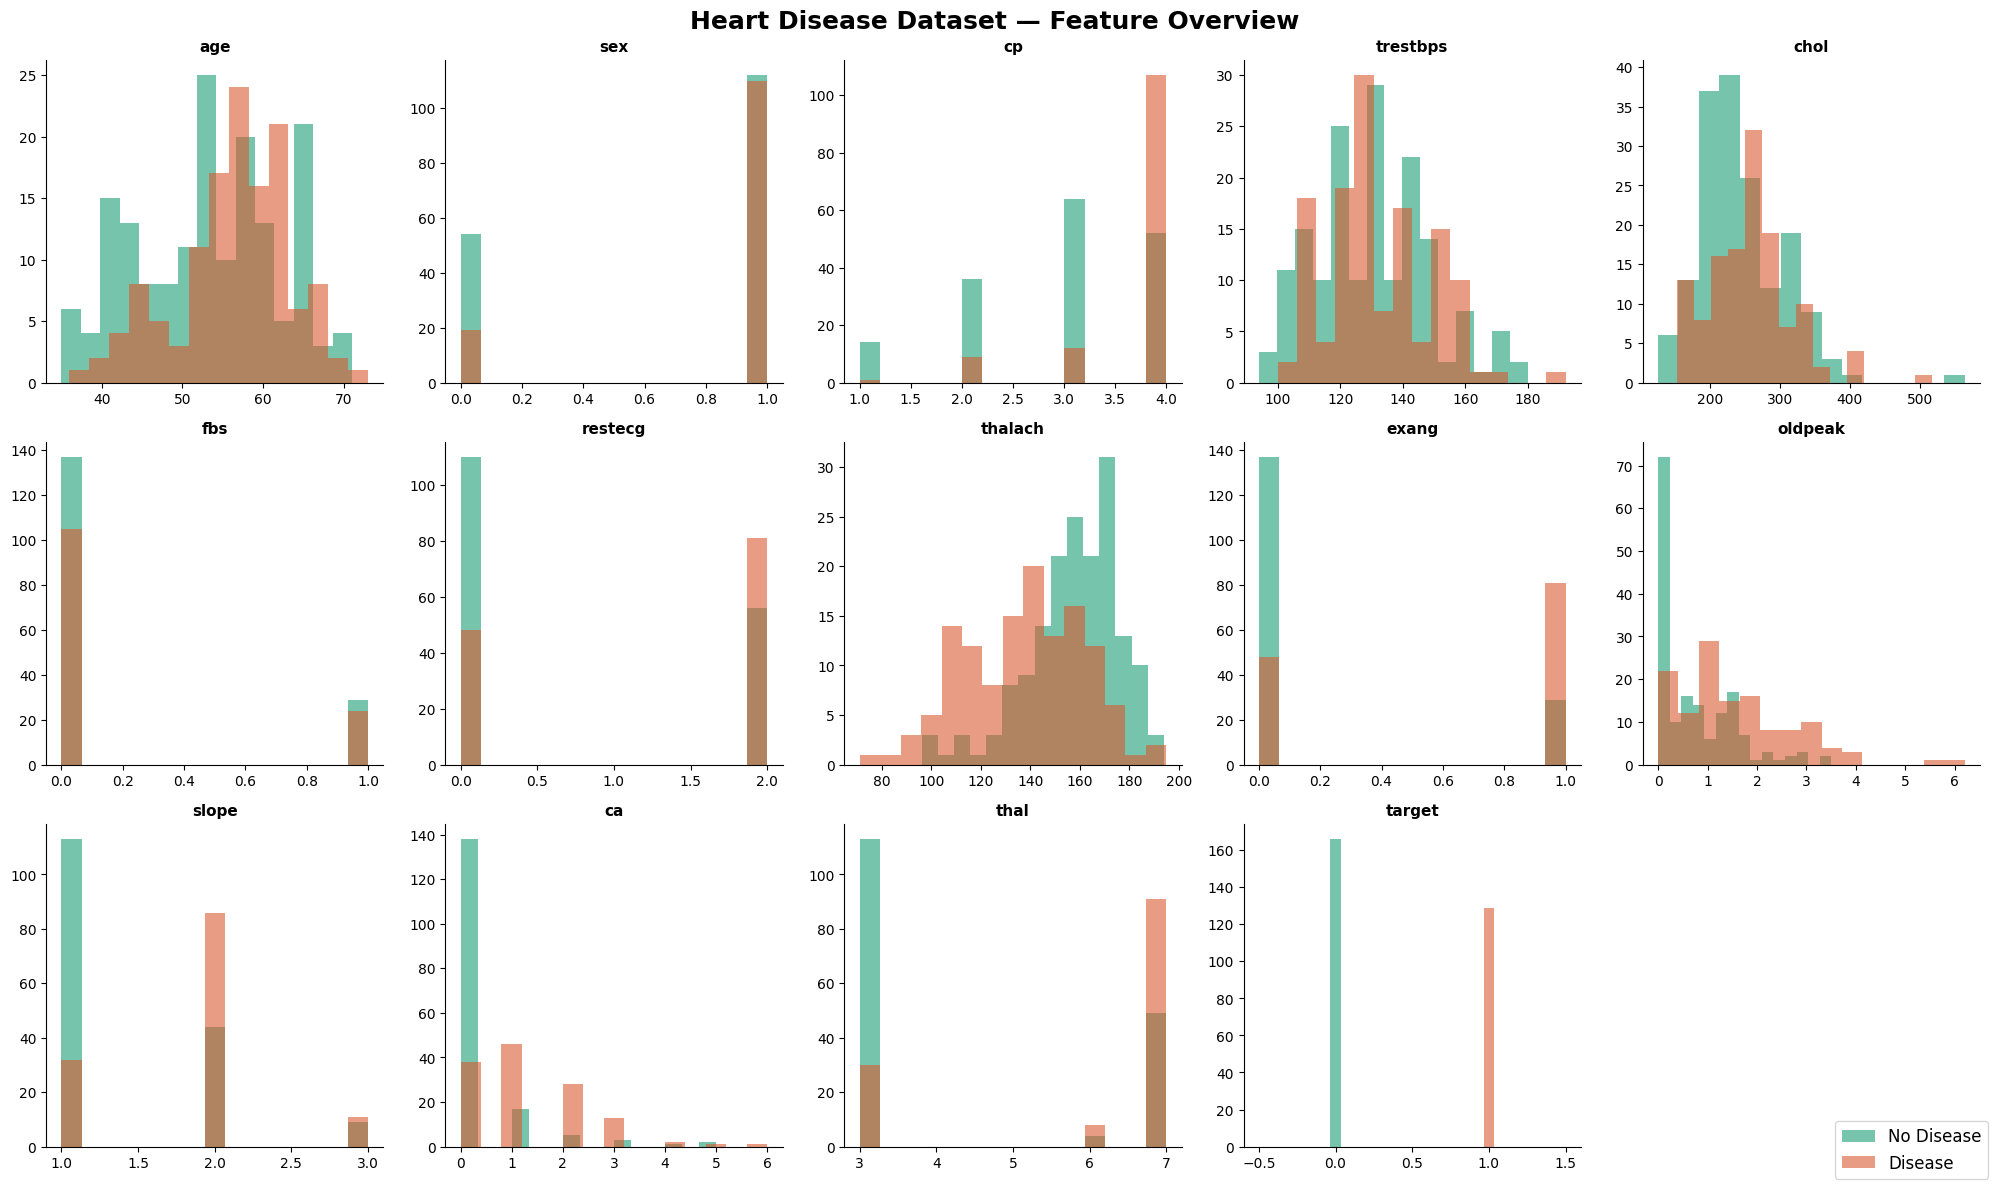

In [5]:
# visualize feature distribution by disease outcome with a bar chart
# green -> no disease, red -> disease
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('Heart Disease Dataset — Feature Overview', fontsize=18, fontweight='bold')

features = ['age', 'sex', 'cp', 'trestbps', 'chol', 
            'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 
            'slope', 'ca', 'thal', 'target']

for i, feat in enumerate(features):
    ax = axes.flatten()[i]
    no_disease = heart_df[heart_df['target'] == 0][feat]
    disease    = heart_df[heart_df['target'] == 1][feat]
    
    ax.hist(no_disease, bins=15, alpha=0.6, color='#1D9E75', label='No Disease')
    ax.hist(disease,    bins=15, alpha=0.6, color='#D85A30', label='Disease')
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes.flatten()[-1].set_visible(False)
fig.legend(['No Disease', 'Disease'], loc='lower right', fontsize=12)
plt.tight_layout()
plt.savefig('figures/phase1_feature_overview.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'df' is not defined

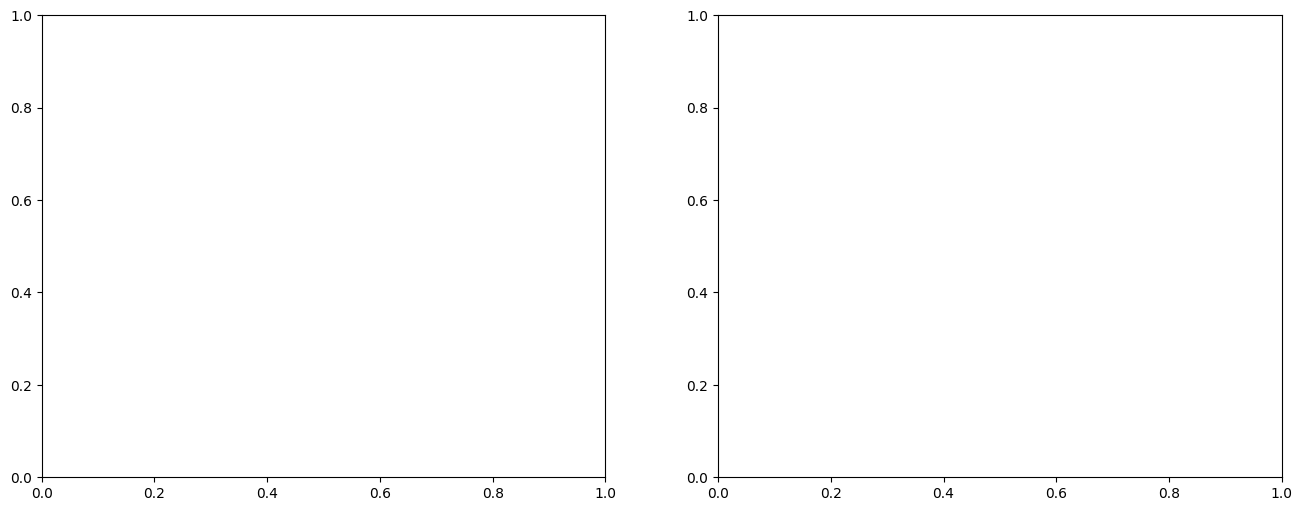

In [6]:
# visualize with a correlation heatmap to identify which features relate to target the most
# bar charts show features with |r| > 0.35 as strong predictors
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: correlation heatmap
corr = df.drop(columns=['num']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', 
            cmap='RdYlGn', center=0, square=True, 
            linewidths=0.5, ax=axes[0],
            annot_kws={'size': 8})
axes[0].set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')

# Right: correlation with target
target_corr = heart_df.drop(columns=['num']).corr()['target'].drop('target').abs().sort_values(ascending=True)
colors = ['#D85A30' if v > 0.35 else '#1D9E75' for v in target_corr.values]
target_corr.plot(kind='barh', ax=axes[1], color=colors)
axes[1].axvline(x=0.35, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Feature Correlation with Target', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Absolute Correlation')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/phase1_correlation.png', dpi=150, bbox_inches='tight')
plt.show()